In [154]:
import os
import sys
import numpy as np

root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)
 
from syn_project.utils_train import *
from syn_project.utils_color_analysis import *
from syn_project.utils_notebook import *

import os
import sys
import numpy as np

root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)
 
from syn_project.utils_train import *
from syn_project.utils_color_analysis import *

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler

%matplotlib widget


In [155]:
condition = "debug4mod"
checkpoint_epoch = 0
n_samples_test = 300
split = "test"


In [156]:
experiment_name = get_experiment_name(condition, "biased_00", 0)
modules = get_setup_modules('syn', experiment_name)
global_workspace = get_global_workspace("syn", experiment_name, epoch=checkpoint_epoch, modules=modules)
data_module = get_data_module("syn",  experiment_name, modules=modules)

test_samples = get_data_samples(data_module, n_samples_test, split=split)
original_colors = test_samples[frozenset({'color'})]['color']
original_v_latents = test_samples[frozenset({'v_latents'})]['v_latents']
cat = test_samples[frozenset({'cat'})]['cat']

domain_mods = global_workspace.domain_mods
gw_mod = global_workspace.gw_mod
latent_domains = global_workspace.encode_domains(test_samples)




Loading model from checkpoint: /home/lucas/gwsyn/checkpoints/syn/debug4mod_biased_00/checkpoints/last.ckpt
Loaded default weights from /home/lucas/gwsyn/checkpoints/syn/debug4mod_biased_00/checkpoints/last.ckpt


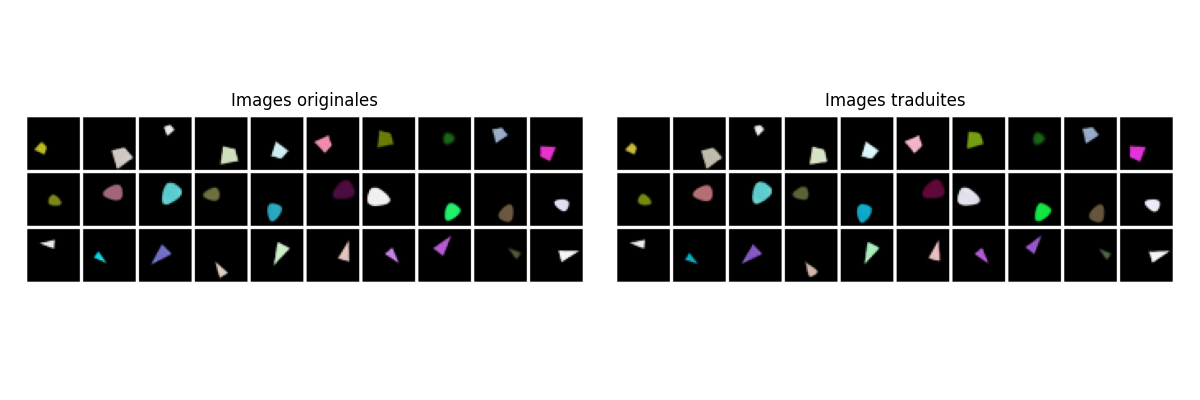

In [157]:
# demi cycle v_latents
domain_name_source = 'v_latents'
latents_source = latent_domains[frozenset({domain_name_source})]

z = gw_mod.encode(latents_source)[domain_name_source]
dcy = gw_mod.decode(z, domains={domain_name_source})

visual_module = cast(VisualLatentDomainModule, global_workspace.domain_mods["v_latents"])

decoded_images_dcy= visual_module.decode_images(dcy['v_latents'])
original_images_rgb = visual_module.decode_images(original_v_latents)

fig = plot_original_translated_comparison(get_n_per_category(original_images_rgb, cat, 10), get_n_per_category(decoded_images_dcy, cat, 10))
plt.show()


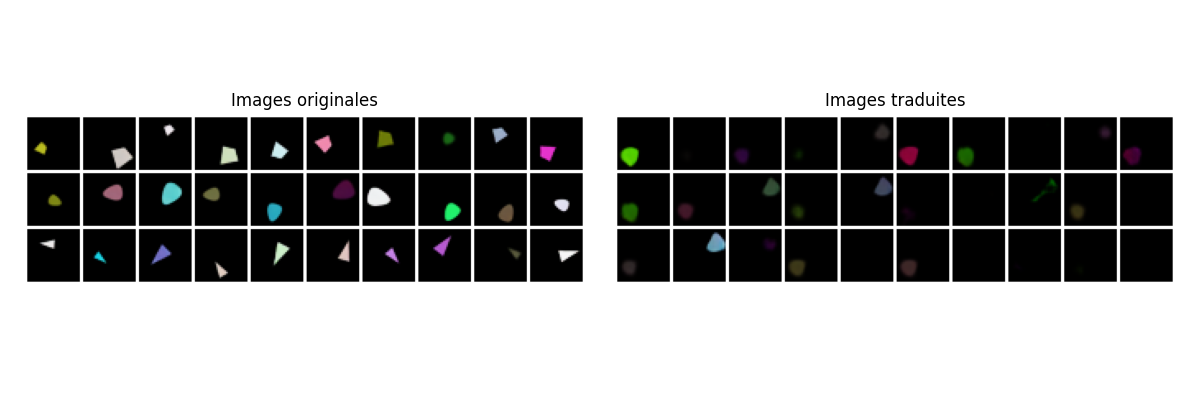

In [158]:
# translation_color_to_v_latents

domain_name_source = 'color'
domain_name_target = 'v_latents'
latents_source = latent_domains[frozenset({domain_name_source})]

z = gw_mod.encode(latents_source)[domain_name_source]
x_pred_2 = gw_mod.decode(z, domains={domain_name_target})

decoded_images_tcv= visual_module.decode_images(x_pred_2['v_latents'])

fig = plot_original_translated_comparison(get_n_per_category(original_images_rgb, cat, 10), get_n_per_category(decoded_images_tcv, cat, 10))
plt.show()


In [159]:
# translation_v_latents_to_color

domain_name_source = 'v_latents'
domain_name_target = 'color'
latents_source = latent_domains[frozenset({domain_name_source})]

z = gw_mod.encode(latents_source)[domain_name_source]
x_pred = gw_mod.decode(z, domains={domain_name_target})

print('truth')
print(original_colors[0:3])
print('pred')
print(x_pred['color'][0:3])

truth
tensor([[0.9961, 0.9294, 0.9255],
        [0.0745, 0.8706, 0.9608],
        [0.4510, 0.4627, 0.8039]], device='cuda:0')
pred
tensor([[0.9379, 0.9078, 0.9332],
        [0.0837, 0.8128, 0.8582],
        [0.4650, 0.4320, 0.7737]], device='cuda:0', grad_fn=<SliceBackward0>)


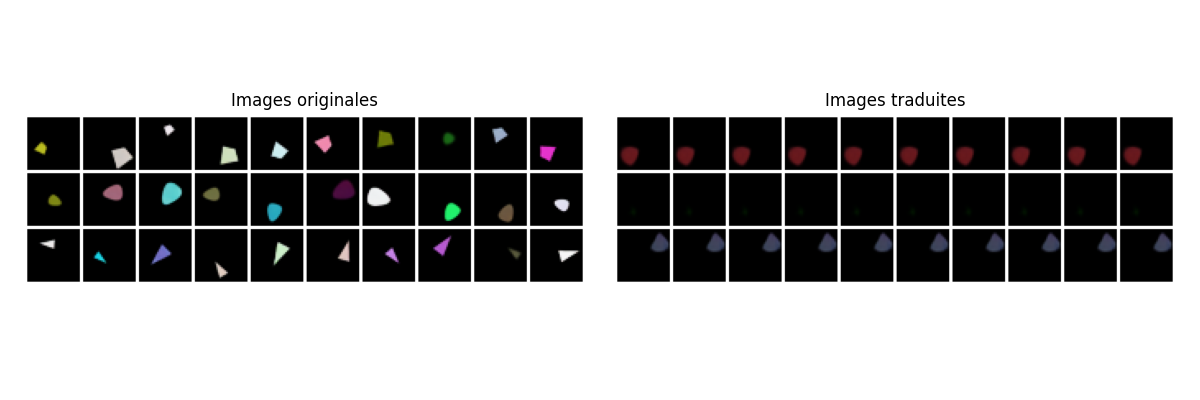

In [160]:
# cat to color to v_latents

# cat_to_color
domain_name_source = 'cat'
domain_name_target = 'color'
latents_source = latent_domains[frozenset({domain_name_source})]

z = gw_mod.encode(latents_source)[domain_name_source]
x_pred = gw_mod.decode(z, domains={domain_name_target})

# translation_color_to_v_latents

domain_name_source = 'color'
domain_name_target = 'v_latents'

z = gw_mod.encode(x_pred)[domain_name_source]
x_pred_3 = gw_mod.decode(z, domains={domain_name_target})

decoded_images_dt= visual_module.decode_images(x_pred_3['v_latents'])

fig = plot_original_translated_comparison(get_n_per_category(original_images_rgb, cat, 10), get_n_per_category(decoded_images_dt, cat, 10))
plt.show()


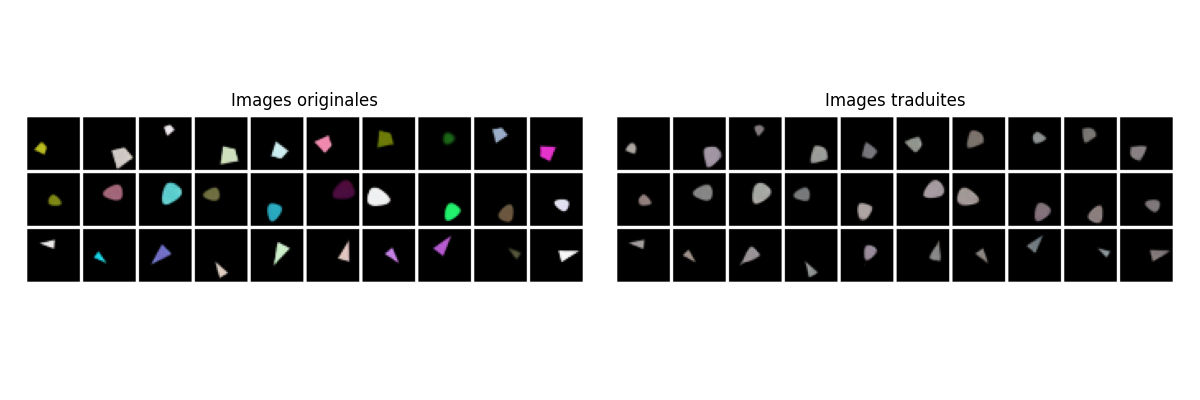

In [161]:
# fustion:cat + position to v_latents
latents_source = latent_domains[frozenset({'color', 'cat', 'position', 'v_latents'})]
p = 0.5

gw_latents = gw_mod.encode(latents_source)
z = p*gw_latents['cat'] + (1-p)*gw_latents['position']

prediction = gw_mod.decode(z, domains={'v_latents'})['v_latents']
decoded_images_f = visual_module.decode_images(prediction)

fig = plot_original_translated_comparison(get_n_per_category(original_images_rgb, cat, 10), get_n_per_category(decoded_images_f, cat, 10))
plt.show()


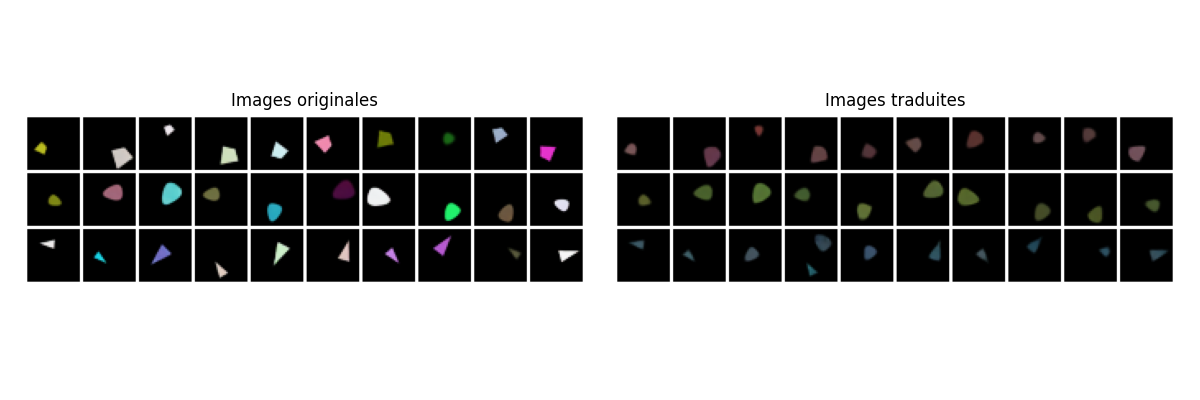

In [162]:
p = 0.7
t = (p)*prediction+ (1-p)*x_pred_3['v_latents']
decoded_images_t= visual_module.decode_images(t)

fig = plot_original_translated_comparison(get_n_per_category(original_images_rgb, cat, 10), get_n_per_category(decoded_images_t, cat, 10))
plt.show()


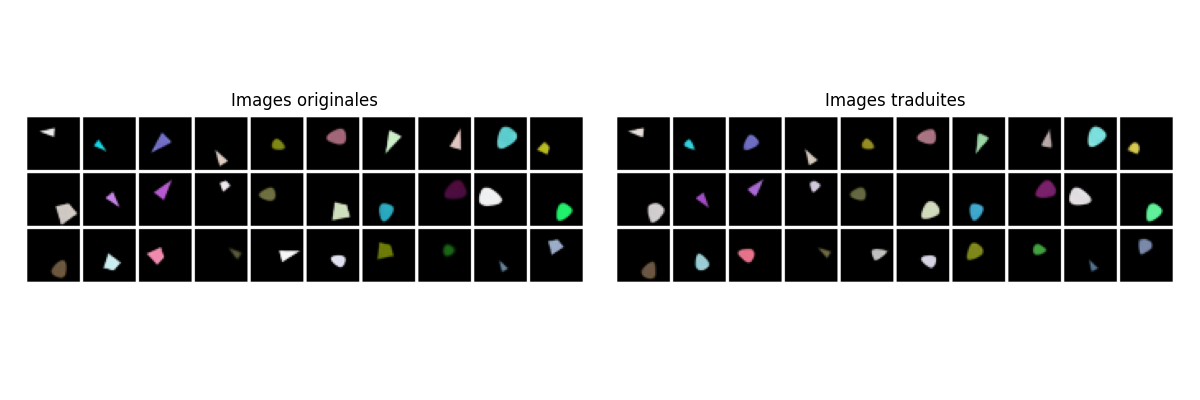

In [163]:
# fustion:cat + position + color to v_latents
latents_source = latent_domains[frozenset({'color', 'cat', 'position', 'v_latents'})]


gw_latents = gw_mod.encode(latents_source)
z = 0.33*gw_latents['color'] + 0.33*gw_latents['cat'] + 0.33*gw_latents['position']

prediction = gw_mod.decode(z, domains={'v_latents'})['v_latents']
decoded_images_f= visual_module.decode_images(prediction)

fig = plot_original_translated_comparison(original_images_rgb, decoded_images_f)
plt.show()


In [164]:
del original_images_rgb
del decoded_images_tcv
del decoded_images_dcy
del decoded_images_tav
del decoded_images_f
del decoded_images_dt
torch.cuda.empty_cache()

NameError: name 'decoded_images_tav' is not defined